# Поиск наилучшего узла

Узлов: 5514 Ребер: 12199
Расчет узлов


426923808 7.355415617070702


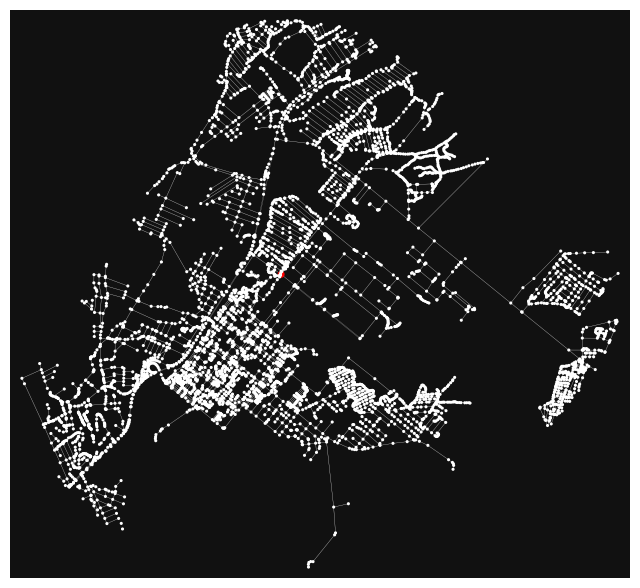

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [1]:
import numpy as np
import networkx as nx
import osmnx as ox

from genesis.algorithms import Graphs
from genesis.metrics import metric_by_time, cover_index
from genesis.swiss_knife import msfpl, ssfpl


G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())

print('Расчет узлов')
calc_node_metric_function = metric_by_time(G,
                            path_function=msfpl,
                            metric_function=np.mean,
                            )
best_node, best_val = Graphs.get_best_node_full(G, 
                          node_metric_function=calc_node_metric_function
                          )
print(best_node, best_val)

nc = ['r' if nd==best_node else 'w' for nd in G.nodes()]
ns = [25 if nd==best_node else 5 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

## Расчет времени прибытия в каждый из узлов

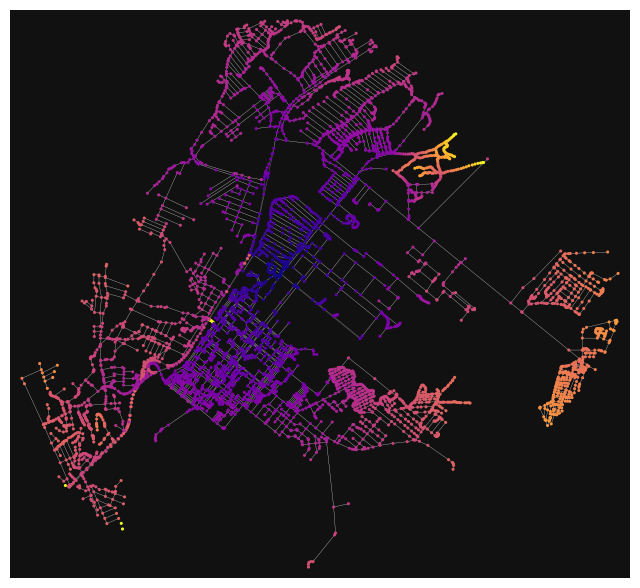

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [2]:
lens = ssfpl(G, best_node, weight = 'travel_time')
mval = max(lens.values())
lens_full = {node:lens[node] if node in lens else mval for node in G.nodes()}

nx.set_node_attributes(G, lens_full, 'route_time')
nc = ox.plot.get_node_colors_by_attr(G, attr="route_time", cmap="plasma")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=5)

## Расчет метрик во всех узлах

In [3]:
route_time_mean = {}
route_time_max = {}
nodes_ip5 = {}

i=0
for node in G.nodes():
    print(f'{i}/{G.number_of_nodes():<5}', end='\r')
    route_time_mean[node] = metric_by_time(G, 
                    path_function=msfpl,
                    metric_function=np.mean,
                    err_val=15)(node)
    route_time_max[node] = metric_by_time(G, 
                    path_function=msfpl, 
                    metric_function=np.max,
                    err_val=20)(node)
    nodes_ip5[node] = metric_by_time(G, 
                    path_function=msfpl, 
                    metric_function=cover_index(ip_val=5),
                    err_val=0)(node)
    i+=1

# Установка значений
nx.set_node_attributes(G, route_time_mean, 'route_time_mean')
nx.set_node_attributes(G, route_time_max, 'route_time_max')
nx.set_node_attributes(G, nodes_ip5, 'nodes_ip5')

# Печать карты со средними значениями
nc = ox.plot.get_node_colors_by_attr(G, attr="route_time_mean", cmap="plasma")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.3)

# Печать карты с максимальными значениями
nc = ox.plot.get_node_colors_by_attr(G, attr="route_time_max", cmap="viridis")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.3)

# Печать карты с значениями ИП-5
nc = ox.plot.get_node_colors_by_attr(G, attr="nodes_ip5", cmap="viridis")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.3)

KeyboardInterrupt: 

## Поиск наилучшего узла из некоторого множества

In [ ]:
nodes = list(G.nodes())
nodes_set = [nodes[50], nodes[200], nodes[500], nodes[1000], nodes[1500], nodes[3000], nodes[4000]]
print(nodes_set)
calc_node_metric_function = metric_by_time(G,
                            path_function=msfpl,
                            metric_function=np.mean,
                            )
best_node, best_val = Graphs.get_best_node_full(G, 
                          node_metric_function=calc_node_metric_function,
                          possible_nodes=nodes_set
                          )
print("лучший узел", best_node, best_val)

print('метрики для каждого из узлов:')
for node in nodes_set:
    m = calc_node_metric_function(node)
    print(node, m)

[426923800, 1526100295, 1555148534, 2034401706, 2034402276, 2760591335, 4901942432]
лучший узел 1555148534 7.822793333848111
метрики для каждого из узлов:
426923800 8.878949760719477
1526100295 13.983186482246678
1555148534 7.822793333848111
2034401706 8.44882116476329
2034402276 11.341234937136626
2760591335 10.595102796316963
4901942432 11.515153311552636


## Расчет лучшего узла алгоритмом стока

In [1]:
import numpy as np
import networkx as nx
import osmnx as ox

from genesis.algorithms import Graphs
from genesis.metrics import metric_by_time, cover_index
from genesis.swiss_knife import msfpl, ssfpl

import random
# import logging as lg
# lg.basicConfig(level=lg.DEBUG)

G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())

Узлов: 5514 Ребер: 12199


426923808 7.355415617070702


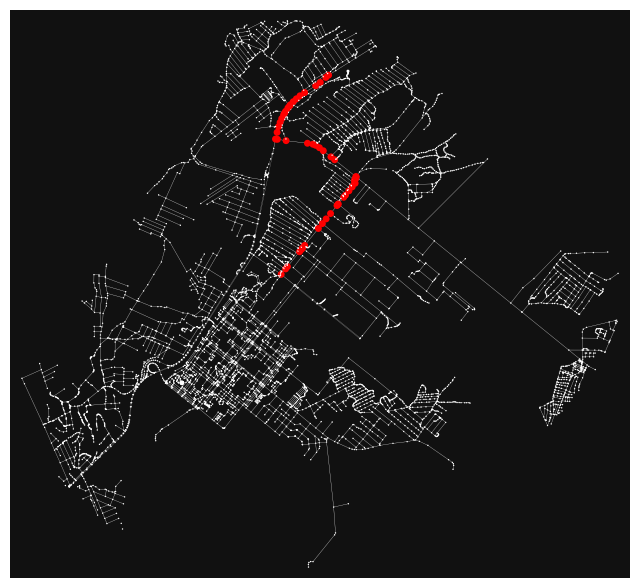

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
# lg.basicConfig(level=lg.DEBUG)
# lg.basicConfig(level=lg.ERROR)
calc_node_metric_function = metric_by_time(G,
                            path_function=msfpl,
                            metric_function=np.mean,
                            )
best_node, best_val, route = Graphs.get_best_node_drain(G, 
                          node_metric_function=calc_node_metric_function
                          )
# lg.basicConfig(level=lg.ERROR)

print(best_node, best_val)
nc = ['r' if nd in route else 'w' for nd in G.nodes()]
ns = [25 if nd in route else 1 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

In [ ]:
calc_node_metric_function = metric_by_time(G,
                            path_function=msfpl,
                            metric_function=np.mean,
                            )
best_node, best_val, route = Graphs.get_best_node_drain(G, 
                          node_metric_function=calc_node_metric_function,
                          all_nodes=True
                          )

print(best_node, best_val)
# nc = ['r' if nd in route else 'w' for nd in G.nodes()]
# ns = [25 if nd in route else 5 for nd in G.nodes()]
# ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

426923808 7.355415617070702


## Расчет метрикой max_time+mean_time

In [2]:
def get_best_node_drain_mm(G, start_node=None):
    '''
    Это в калькуляторы

    Minimum travel time location problem - MTTLP
    '''
    calc_node_metric_function = metric_by_time(G,
                                path_function=msfpl,
                                metric_function=np.max,
                                )
    best_node, best_val, _ = Graphs.get_best_node_drain(G, 
                            node_metric_function=calc_node_metric_function,
                            start_node=start_node
                            )

    calc_node_metric_function = metric_by_time(G,
                                path_function=msfpl,
                                metric_function=np.mean,
                                )
    best_node, best_val, _ = Graphs.get_best_node_drain(G, 
                            node_metric_function=calc_node_metric_function,
                            start_node=best_node
                            )
    return best_node, best_val


print('Без стартового узла:', get_best_node_drain_mm(G))
node = 2712076294
print('Со стартовым узлом', get_best_node_drain_mm(G, node))

Без стартового узла: (426923808, 7.355415617070702)


Со стартовым узлом (426923808, 7.355415617070702)


С использованием функции из `algorithms.Graphs`

In [3]:
# Оценка для неизвестного стартового узла
cur_node, cur_val = Graphs.get_best_node_drain_max_mean(G, path_function=msfpl)
print('Оценка для неизвестного стартового узла', cur_node, cur_val)

# Оценка для известного стартового узла
cur_node, cur_val = Graphs.get_best_node_drain_max_mean(G, path_function=msfpl, start_node=list(G.nodes())[300])
print('Оценка для известного стартового узла', cur_node, cur_val)

Оценка для неизвестного стартового узла 426923808 7.355415617070702


TypeError: metric_by_time() got an unexpected keyword argument 'start_node'

### Расчет для нескольких узлов последовательно

С использованием функции из `algorithms.Graphs`

Расчет узла 2054468666
426923808 7.355415617070702
Расчет узла 4796091623
426923808 7.355415617070702
Расчет узла 4796070861
426923808 7.355415617070702
Расчет узла 2054468644
426923808 7.355415617070702
Расчет узла 2042076517
426923808 7.355415617070702
Расчет узла 9994288430
426923808 7.355415617070702
Расчет узла 2034401348
426923808 7.355415617070702
Расчет узла 9060052053
426923808 7.355415617070702
Расчет узла 3119947227
426923808 7.355415617070702
Расчет узла 4116052097
426923808 7.355415617070702
Расчет узла 2054469016
426923808 7.355415617070702
Расчет узла 2034402813
426923808 7.355415617070702
Расчет узла 4336348792
426923808 7.355415617070702
Расчет узла 2054468689
426923808 7.355415617070702
Расчет узла 2054469188
426923808 7.355415617070702
Расчет узла 3981428902
426923808 7.355415617070702
Расчет узла 3981463644
426923808 7.355415617070702
Расчет узла 4796070876
426923808 7.355415617070702
Расчет узла 4796091618
426923808 7.355415617070702
Расчет узла 2932152230
42692380

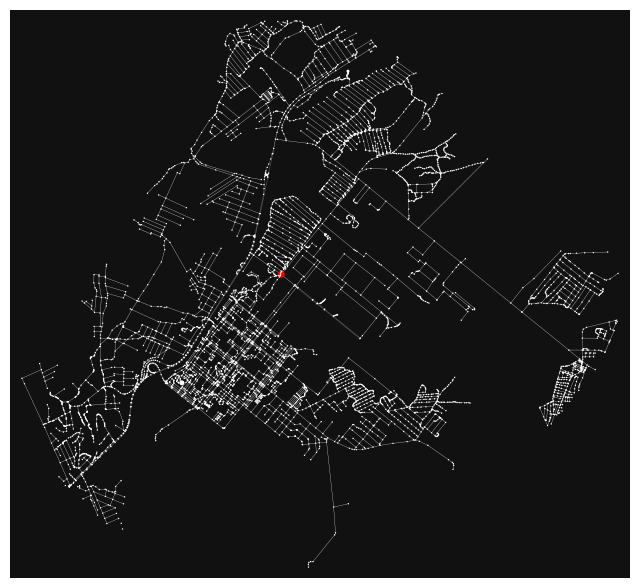

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
sample_size = 10
start_nodes = random.sample(list(G.nodes()), sample_size)
start_nodes

best_val = 1000
best_node
for node in start_nodes:
    print('Расчет узла', node)
    try:
        cur_node, cur_val = Graphs.get_best_node_drain_max_mean(G, node)
        print(cur_node, cur_val)
    except ValueError:
        print(f'Узел {node} неприемлем')                               
    if cur_val<best_val:
        best_val = cur_val
        best_node = cur_node

print(best_node, best_val)

nc = ['r' if nd==best_node else 'w' for nd in G.nodes()]
ns = [25 if nd==best_node else 1 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

# Расчет ячеек Вороного

In [1]:
import numpy as np
import networkx as nx
import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt

from genesis.algorithms import Graphs
from genesis.metrics import metric_by_time, cover_index
from genesis.swiss_knife import msfpl, ssfpl

import random
# import logging as lg
# lg.basicConfig(level=lg.DEBUG)

G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())

Узлов: 5514 Ребер: 12199


In [ ]:
nodes_list = list(G.nodes())
centers = [nodes_list[20], nodes_list[200]]
print('центры', centers)
voronoi = nx.voronoi_cells(G, centers, weight='travel_time')
voronoi
# тупиковый путь - так как все-равно нужно добавлять функционал обрезки по границам

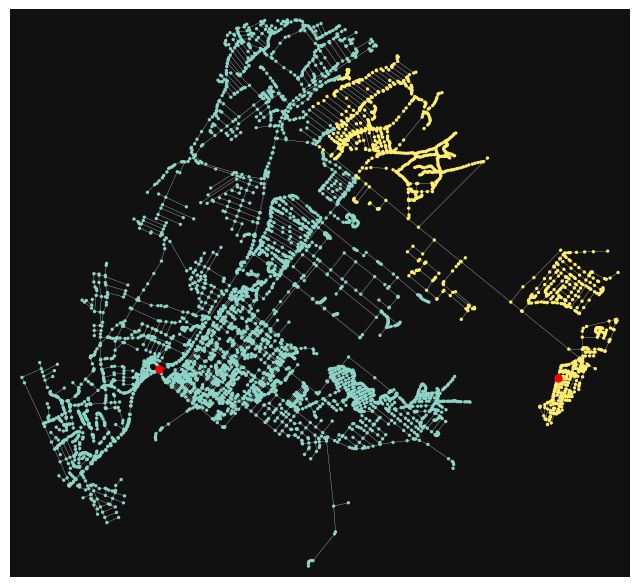

In [85]:
# Верный путь!
def calc_route_times(G:nx.MultiDiGraph,
                        sources:list|dict,
                        path_function,
                        weight: str = 'travel_time',
                        route_name = 'route_time',
                        nearest_name = 'nearest',
                        cutoff=None,
                        all_nodes_times=False,
                        all_nodes_pattern='node_{}'
                        ):

    # Проверка типов входящих данных
    if isinstance(sources, list):
        if isinstance(sources, list):
            if len(sources)==0:
                raise ValueError('В sources нет ни одного элемента!')
            for element in sources:
                if not isinstance(element, int):
                    raise TypeError("Все идентификаторы узлов в списке sources должны иметь тип данных int!")
                if not element in G.nodes():
                    raise KeyError(f"Узел {element} отсутствует в графе G")
    elif isinstance(sources, dict):
        if len(sources)==0:
            raise ValueError('В sources нет ни одного элемента!')
        for node, name in sources.items():
            if not isinstance(name, str):
                raise TypeError("Все имена узлов в словаре sources должны иметь тип данных str!")
            if not node in G.nodes():
                raise KeyError(f"Узел {node} отсутствует в графе G")
    else:
        raise TypeError("Идентификатор узла должен иметь тип данных int или list(int)!")
    if not isinstance(G, nx.MultiDiGraph):
        raise TypeError("Аргумент G должен иметь тип nx.MultiDiGraph!")

    # Расчет
    times, routes = path_function(G, sources=sources, cutoff=cutoff, weight=weight)
    times = pd.Series(times)
    if isinstance(sources, dict):
        nearest = pd.Series({k:sources[route[0]] for k, route in routes.items()}, dtype=str)
    else:
        nearest = pd.Series({k:route[0] for k, route in routes.items()}, dtype='int64')
    
    # Установка результатов расчета в качестве атрибутов ребер
    nx.set_node_attributes(G, times, route_name)
    nx.set_node_attributes(G, nearest, nearest_name)





nodes_list = list(G.nodes())
sources = {nodes_list[100]:'ПСЧ-1',
         nodes_list[2000]:'ПСЧ-22'}
# sources = [nodes_list[100], nodes_list[2000]]

calc_route_times(G, sources, nx.multi_source_dijkstra)

nds = ox.graph_to_gdfs(G, edges=False)
fig, ax = ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False)
# nds.plot(ax=ax, markersize=2, column='route_time')
nds.plot(ax=ax, markersize=2, column='nearest', cmap='Set3')
nds.loc[sources.keys()].plot(ax=ax, markersize=25, color='red')
plt.show()

In [87]:
# import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap  #, ListedColormap

colors = ["green", "yellow", "red"]
cmap1 = LinearSegmentedColormap.from_list("mycmap", colors)

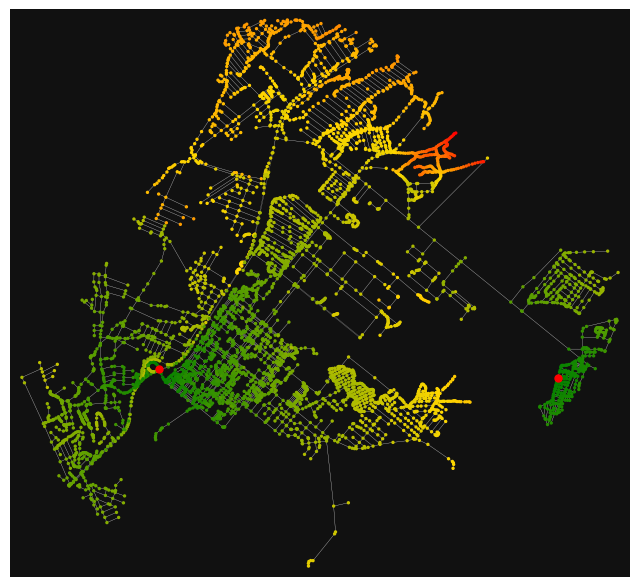

In [89]:
cmap1 = LinearSegmentedColormap.from_list("mycmap", ["green", "gold", "red"])

nds = ox.graph_to_gdfs(G, edges=False)
fig, ax = ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False)
nds.plot(ax=ax, markersize=2, column='route_time', cmap=cmap1)
# nds.plot(ax=ax, markersize=2, column='nearest')
nds.loc[sources.keys()].plot(ax=ax, markersize=25, color='red')
plt.show()

In [22]:
nds = ox.graph_to_gdfs(G, edges=False)
nds.query('nearest=="ПСЧ-1"')

,y,x,street_count,route_time,nearest,highway,geometry
osmid,,,,,,,


In [16]:
nds.query('nearest=="ПСЧ-22"')

,y,x,street_count,route_time,nearest,highway,geometry
osmid,,,,,,,
290700436,56.116593,93.309483,3,0.297886,ПСЧ-22,NaN,POINT (93.30948 56.11659)
290700439,56.116000,93.308877,2,0.428072,ПСЧ-22,NaN,POINT (93.30888 56.11600)
290700442,56.115449,93.308472,2,0.541536,ПСЧ-22,NaN,POINT (93.30847 56.11545)
290700445,56.114823,93.308154,2,0.665617,ПСЧ-22,NaN,POINT (93.30815 56.11482)
290700446,56.114246,93.307977,2,0.777279,ПСЧ-22,NaN,POINT (93.30798 56.11425)
...,...,...,...,...,...,...,...
10861562817,56.123782,93.301762,4,2.501880,ПСЧ-22,NaN,POINT (93.30176 56.12378)
10861562818,56.123778,93.302198,4,2.549609,ПСЧ-22,NaN,POINT (93.30220 56.12378)
10861562819,56.123544,93.304071,3,2.760424,ПСЧ-22,NaN,POINT (93.30407 56.12354)


# Расчет для способа "от каждого узла к каждому узлу"

Проверка расчета для случая когда требуется рассчитать время прибытия из каждого стартового узла (мест размещения подразделений) в каждый узел графа. Пригодится для расчета по методике из СП 11.13130

In [18]:
import numpy as np
import networkx as nx
import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt

from genesis.algorithms import Graphs
from genesis.metrics import metric_by_time, cover_index
from genesis.swiss_knife import msf
from genesis.tools import Progressbar


import random
# import logging as lg
# lg.basicConfig(level=lg.DEBUG)

G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())

Узлов: 5514 Ребер: 12199


In [2]:
objects_list= random.sample(list(G.nodes()), 50)

Graphs.calc_route_times(G, sources=objects_list, path_function=msf,
                        each_to_each=True)

In [4]:
df = ox.graph_to_gdfs(G, edges=False)
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 5514 entries, 290700344 to 10861562821
Data columns (total 55 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   y                 5514 non-null   float64 
 1   x                 5514 non-null   float64 
 2   street_count      5514 non-null   int64   
 3   node_2034401938   5504 non-null   float64 
 4   node_9821566435   5504 non-null   float64 
 5   node_2034402270   5504 non-null   float64 
 6   node_6001978586   5504 non-null   float64 
 7   node_4058013691   5504 non-null   float64 
 8   node_426923809    5504 non-null   float64 
 9   node_2054468538   5504 non-null   float64 
 10  node_2054468674   5504 non-null   float64 
 11  node_8922691085   5504 non-null   float64 
 12  node_2034401731   5504 non-null   float64 
 13  node_2034401523   5504 non-null   float64 
 14  node_8089452709   5504 non-null   float64 
 15  node_2034402378   5504 non-null   float64 
 16  node_4

In [13]:
columns_list = [col for col in df.columns if 'node_' in col]
matrix = df[columns_list]
matrix.loc[290700344].max()

19.18673657142859

Полностью:

In [23]:
# Список узлов в которых расположены расчетные объекты
objects_list= random.sample(list(G.nodes()), 150)

In [29]:
def metric_by_matrix(matrix):
    '''
    Функция определения метрики по заранее рассчитанной матрице кратчайших расстояний
    '''
    def _metric_by_matrix(node):
        return matrix.loc[node].max()
    return _metric_by_matrix


# Реверс графа, для расчета не от объектов а к ним
G = nx.reverse(G)

# Расчет времен прибытия из каждого объекта (в дальнейшем заменить развернутой функцией!!!)
Graphs.calc_route_times(G, sources=objects_list, path_function=msf,
                        each_to_each=True)

# Получение датафрейма с временами прибытия из каждого объекта в каждый из узов графа
df = ox.graph_to_gdfs(G, edges=False)
columns_list = [col for col in df.columns if 'node_' in col]
matrix = df[columns_list]

# Собственно определение лучшего узла полным перебором по матрице
calc_node_metric_function = metric_by_matrix(matrix)
best_node, best_val = Graphs.get_best_node_full(G,
                    node_metric_function=calc_node_metric_function,
                    event_after_node_calc=Progressbar(G.number_of_nodes())
                    )
print(best_node, best_val)

3981463578 0.000.0%


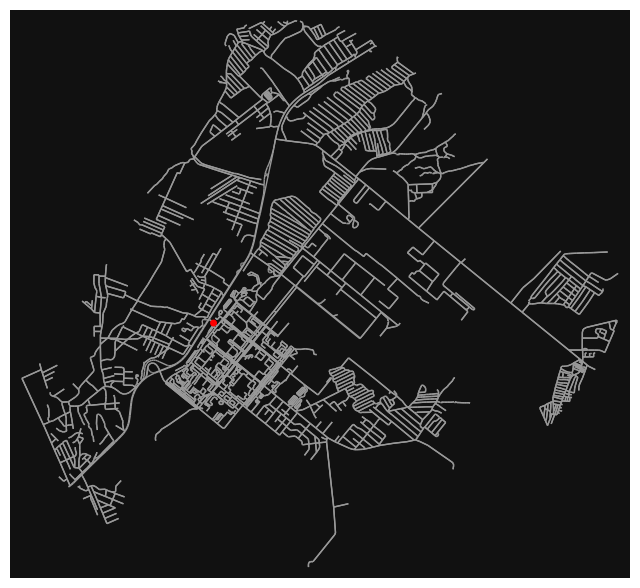

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [30]:
nc = ['r' if nd == best_node else 'w' for nd in G.nodes()]
ns = [25 if nd == best_node else 0 for nd in G.nodes()]

ox.plot_graph(G, node_color=nc, node_size=ns)

# Тесты

In [46]:
s = 'node_{}'
print(s.format(79))

node_79


In [ ]:
import numpy as np
import networkx as nx
import osmnx as ox

from genesis.algorithms import Graphs
from genesis.metrics import calc_node_metric, cover_index
from genesis.swiss_knife import msfpl, ssfpl


In [ ]:
def create_G():
    '''
        max: 21
        mean: 8.67
        median: 8.0
        ip-10: 66.67
        ip-20: 93.33
    '''
    G = nx.MultiDiGraph()
    G.add_edge(1, 2, key=0, travel_time=3)
    G.add_edge(1, 3, key=0, travel_time=2)
    G.add_edge(1, 4, key=0, travel_time=5)
    G.add_edge(2, 3, key=0, travel_time=2)
    G.add_edge(2, 5, key=0, travel_time=5)
    G.add_edge(2, 6, key=0, travel_time=7)
    G.add_edge(3, 2, key=0, travel_time=3)
    G.add_edge(3, 7, key=0, travel_time=3)
    G.add_edge(3, 8, key=0, travel_time=4)
    G.add_edge(3, 9, key=0, travel_time=5)
    G.add_edge(4, 3, key=0, travel_time=2)
    G.add_edge(4, 8, key=0, travel_time=4)
    G.add_edge(4, 10, key=0, travel_time=12)
    G.add_edge(4, 11, key=0, travel_time=10)
    G.add_edge(5, 8, key=0, travel_time=8)
    G.add_edge(5, 10, key=0, travel_time=8)
    G.add_edge(5, 12, key=0, travel_time=6)
    G.add_edge(5, 13, key=0, travel_time=9)
    G.add_edge(5, 12, key=0, travel_time=8)
    G.add_edge(6, 8, key=0, travel_time=1)
    G.add_edge(6, 9, key=0, travel_time=4)
    G.add_edge(6, 12, key=0, travel_time=4)
    G.add_edge(7, 10, key=0, travel_time=4)
    G.add_edge(7, 11, key=0, travel_time=9)
    G.add_edge(7, 13, key=0, travel_time=7)
    G.add_edge(8, 10, key=0, travel_time=6)
    G.add_edge(8, 13, key=0, travel_time=8)
    G.add_edge(9, 14, key=0, travel_time=10)
    G.add_edge(10, 13, key=0, travel_time=7)
    G.add_edge(10, 14, key=0, travel_time=5)
    G.add_edge(11, 12, key=0, travel_time=7)
    G.add_edge(11, 15, key=0, travel_time=7)
    G.add_edge(12, 13, key=0, travel_time=8)
    return G

G = create_G()
nodes_list=[2,5,8]
best_node, best_val = Graphs.get_best_node_full(G,
                        path_function=msfpl,
                        metric_function=np.mean,
                        possible_nodes=nodes_list,
                        appr_val=0.5
                        )
print(best_node, best_val)

print('метрики для каждого из узлов:')
for node in nodes_list:
    m = calc_node_metric(G,
                     node,
                     path_function=msfpl,
                     metric_function=np.mean,
                     appr_val=0.5,
                     err_val=0)
                    #  err_val='pass')
    print(node, m)

2 8.69
метрики для каждого из узлов:
2 8.69
5 0
8 0


In [ ]:
best_node, best_val = Graphs.get_best_node_full(G,
                            path_function=msfpl,
                            metric_function=cover_index(),
                            # appr_val=0,
                            reduce=False
                            )
print(best_node, best_val)

1 66.67


In [ ]:
print('метрики для каждого из узлов:')
for node in G.nodes():
    m = calc_node_metric(G,
                     node,
                     path_function=msfpl,
                     metric_function=cover_index(),
                    #  err_val=0)
                     err_val='pass')
    print(node, m)

метрики для каждого из узлов:
1 66.67
2 61.54
3 69.23
4 64.29
5 83.33
6 85.71
7 71.43
8 75.0
9 100.0
10 100.0
11 75.0
12 100.0
13 100.0
14 100.0
15 100.0


In [ ]:
print('метрики для каждого из узлов:')
for node in G.nodes():
    m = calc_node_metric(G,
                     node,
                     path_function=msfpl,
                     metric_function=cover_index(),
                     appr_val=0.5,
                     err_val=0)
                    #  err_val='pass')
    print(node, m)

метрики для каждого из узлов:
1 66.67
2 61.54
3 69.23
4 64.29
5 0
6 85.71
7 71.43
8 0
9 0
10 0
11 0
12 0
13 0
14 0
15 0


In [ ]:
print('метрики для каждого из узлов:')
for node in G.nodes():
    m = calc_node_metric(G,
                     node,
                     path_function=msfpl,
                     metric_function=cover_index(),
                     appr_val=1,
                        )
                    # err_val=0)
                    #  err_val='pass')
    print(node, m)

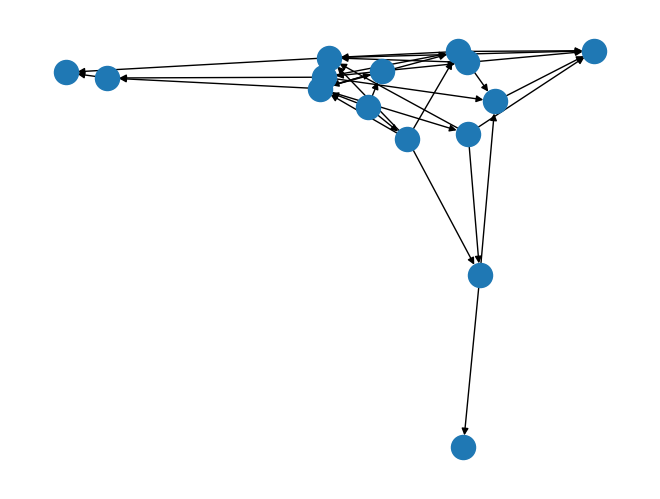

In [ ]:
nx.draw(G, pos=nx.spring_layout(G))

In [ ]:
pn = None
bn = list(G.nodes())[0]
bn==pn

False

In [ ]:
def create_G():
    '''
        max: 21
        mean: 8.67
        median: 8.0
        ip-10: 66.67
        ip-20: 93.33
    '''
    G = nx.MultiDiGraph()
    G.add_edge(1, 2, key=0, travel_time=3)
    G.add_edge(1, 3, key=0, travel_time=2)
    G.add_edge(1, 4, key=0, travel_time=5)
    G.add_edge(2, 3, key=0, travel_time=2)
    G.add_edge(2, 5, key=0, travel_time=5)
    G.add_edge(2, 6, key=0, travel_time=7)
    G.add_edge(3, 2, key=0, travel_time=3)
    G.add_edge(3, 7, key=0, travel_time=3)
    G.add_edge(3, 8, key=0, travel_time=4)
    G.add_edge(3, 9, key=0, travel_time=5)
    G.add_edge(4, 3, key=0, travel_time=2)
    G.add_edge(4, 8, key=0, travel_time=4)
    G.add_edge(4, 10, key=0, travel_time=12)
    G.add_edge(4, 11, key=0, travel_time=10)
    G.add_edge(5, 8, key=0, travel_time=8)
    G.add_edge(5, 10, key=0, travel_time=8)
    G.add_edge(5, 12, key=0, travel_time=6)
    G.add_edge(5, 13, key=0, travel_time=9)
    G.add_edge(5, 12, key=0, travel_time=8)
    G.add_edge(6, 8, key=0, travel_time=1)
    G.add_edge(6, 9, key=0, travel_time=4)
    G.add_edge(6, 12, key=0, travel_time=4)
    G.add_edge(7, 10, key=0, travel_time=4)
    G.add_edge(7, 11, key=0, travel_time=9)
    G.add_edge(7, 13, key=0, travel_time=7)
    G.add_edge(8, 10, key=0, travel_time=6)
    G.add_edge(8, 13, key=0, travel_time=8)
    G.add_edge(9, 14, key=0, travel_time=10)
    G.add_edge(10, 13, key=0, travel_time=7)
    G.add_edge(10, 14, key=0, travel_time=5)
    G.add_edge(11, 12, key=0, travel_time=7)
    G.add_edge(11, 15, key=0, travel_time=7)
    G.add_edge(12, 13, key=0, travel_time=8)
    return G

G = create_G()

In [ ]:
for edge in G.in_edges(2):
    print(edge[0])

1
3


In [ ]:
for edge in G.out_edges(2):
    print(edge[1])

3
5
6


In [ ]:
G.add_edge(1, 2, key=0, travel_time=3)
G.add_edge(3, 2, key=0, travel_time=3)
G.add_edge(2, 3, key=0, travel_time=2)
G.add_edge(2, 5, key=0, travel_time=5)
G.add_edge(2, 6, key=0, travel_time=7)

In [ ]:
G[3]

AdjacencyView({2: {0: {'travel_time': 3}}, 7: {0: {'travel_time': 3}}, 8: {0: {'travel_time': 4}}, 9: {0: {'travel_time': 5}}})

In [42]:
import time

class Progressbar(object):

    def __init__(self, maxval, minval=0, bins=10):
        self.maxval = maxval
        self.minval = minval
        self.bins = bins
        self.scope = maxval-minval
        self.val=minval

    def __call__(self):
        self.val+=1
        bins_ok = int(self.bins*(self.val/self.scope))
        bins_still = self.bins-bins_ok
        s = "|"+"#"*bins_ok + "_"*bins_still + "| " + f'{round(100*self.val/self.scope, 1)}%'
        print(s, end='\r')

pb = Progressbar(60, bins=50)
for i in range(60):
    pb()
    time.sleep(0.25)

In [43]:
#%% Исследование качества алгоритмов поиска лучшего узла
import numpy as np
import pandas as pd
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt
from tabulate import tabulate

from genesis.algorithms import Graphs
from genesis.metrics import metric_by_time, cover_index
from genesis.swiss_knife import msfpl, ssfpl

import random
import time


#%% Загрузка графа
G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())


#%% Стратегия уменьшения максимального времени следования
results = pd.DataFrame()
i=0
#%% Оценка лучшего узла полным перебором
start_time=time.time()
calc_node_metric_function = metric_by_time(G,
                            path_function=msfpl,
                            metric_function=np.max,
                            )
best_node, best_val = Graphs.get_best_node_full(G, 
                          node_metric_function=calc_node_metric_function,
                          event_after_node_calc=Progressbar(G.number_of_nodes(), bins=100)
                          )
end_time=time.time()
print('Лучший узел:', best_node, best_val, f't={round(end_time-start_time,2)} сек.', sep='\t', end='\n\n')
results.loc[i, 'method'] = 'bnf'
results.loc[i, 'strategy'] = 'снижение max_time'
results.loc[i, 'best_node'] = best_node
results.loc[i, 'best_val'] = best_val
results.loc[i, 'calc_time'] = round(end_time-start_time,2)
nc = ['r' if nd==best_node else 'w' for nd in G.nodes()]
ns = [25 if nd==best_node else 1 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

Узлов: 5514 Ребер: 12199


KeyboardInterrupt: 